In [107]:
import numpy as np 
import pandas as pd 
import os
import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img,img_to_array
from IPython.display import Image
from IPython.display import display
from PIL import Image
print(tf.__version__)

2.10.0


In [108]:
physical_devices = tf.config.experimental.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))
tf.config.experimental.set_memory_growth(physical_devices[0], True)

Num GPUs Available:  1


In [109]:
#Loading Fine-Tuned Model
model = tf.keras.models.load_model('C:/Users/Rafin/OneDrive/Desktop/NSU/NSU 10th Semester/CSE299/PROJECT/CSE299.1_CalorieMate/MobileNet_Test/Food_FineTuned_V2.h5')

In [110]:
# Create a list with the filepaths for labeling
label_dir = Path(r'C:/Users/Rafin/OneDrive/Desktop/NSU/NSU 10th Semester/CSE299/PROJECT/CSE299.1_CalorieMate/MobileNet_Test/Bangla_Food58_V2/train')
label_filepaths = list(label_dir.glob(r'**/*.jpg'))

In [111]:
#Preparing images to be loaded into model
def image_processing(filepath):
    labels = [str(filepath[i]).split("\\")[-2] \
        for i in range(len(filepath))]
    filepath = pd.Series(filepath, name='Filepath').astype(str)
    labels = pd.Series(labels, name='Label')
    df = pd.concat([filepath, labels], axis=1)
    df = df.sample(frac=1).reset_index(drop = True)
    return df

In [112]:
#Label DataFrame
label_df = image_processing(label_filepaths)

In [113]:
label_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [114]:
label_images = label_generator.flow_from_dataframe(
    dataframe=label_df,
    x_col='Filepath',
    y_col='Label',
)

Found 23905 validated image filenames belonging to 58 classes.


In [125]:
# Map the label
labels = (label_images.class_indices)
labels = dict((v,k) for k,v in labels.items())
print(labels)

{0: 'Alu Bhorta', 1: 'Alu-Vaji', 2: 'Begun Bhaja', 3: 'Begun Bhorta', 4: 'Biriyani', 5: 'Boiled_egg', 6: 'Borhani', 7: 'Burger', 8: 'Cake', 9: 'Chicken_Grill', 10: 'Chicken_curry', 11: 'Chicken_wings', 12: 'Chitoi  Pitha', 13: 'Chocolate_cake', 14: 'Doi', 15: 'Falooda', 16: 'Fish Bhuna_Mach Bhuna', 17: 'French_fries', 18: 'Fried chicken - Murg Bhaja', 19: 'Fried fish_Mach Bhaja', 20: 'Fried_rice', 21: 'Fuchka', 22: 'Hilsha_Fish_Curry', 23: 'Jalebi', 24: 'Jorda', 25: 'Kacchi', 26: 'Khichuri', 27: 'Korola-Vaji', 28: 'Lal-shak-Vaji', 29: 'Lentil fritters - Dal Puri', 30: 'Lentil soup_Dal', 31: 'Meat Curry_Gosht Bhuna', 32: 'Misti', 33: 'Mixed vegetable stir-fry - Torkari', 34: 'Momo', 35: 'Noodles', 36: 'Parata', 37: 'Payesh-Firni', 38: 'Prawn curry - Chingri bhuna', 39: 'Rice', 40: 'Rosogolla', 41: 'Salad', 42: 'Sandwich', 43: 'Shak-Vaji', 44: 'Shawarma', 45: 'Shemai', 46: 'Shik_kabab', 47: 'Singgara', 48: 'Sondesh', 49: 'Tundul ruti - Nan Ruti', 50: 'Vapa Pitha', 51: 'Vegetable fritters

In [116]:
def output(location):
    img=load_img(location,target_size=(224,224,3))
    img=img_to_array(img)
    img=img/255
    img=np.expand_dims(img,[0])
    answer=model.predict(img)
    y_class = answer.argmax(axis=-1)
    y = " ".join(str(x) for x in y_class)
    y = int(y)
    res = labels[y]
    return res

In [117]:
#Loop through all files in this directory and Predict(for testing)
source_directory = r'C:/Users/Rafin/OneDrive/Desktop/NSU/NSU 10th Semester/CSE299/PROJECT/CSE299.1_CalorieMate/MobileNet_Test_Images'
for subdirectory_name in os.listdir(source_directory):
     subdirectory_path = os.path.join(source_directory, subdirectory_name)

     print(subdirectory_name)
     img = output(subdirectory_path)
     print('Predicted as - ', img, '\n')

b.jpg
1/1 [==============================] - 1s 671ms/step
Predicted as -  Noodles 

c.jpg
1/1 [==============================] - 0s 20ms/step
Predicted as -  Meat Curry_Gosht Bhuna 

download.jpg
1/1 [==============================] - 0s 24ms/step
Predicted as -  Singgara 

e.jpg
1/1 [==============================] - 0s 25ms/step
Predicted as -  Shawarma 

f.jpg
1/1 [==============================] - 0s 24ms/step
Predicted as -  Lal-shak-Vaji 

g.jpg
1/1 [==============================] - 0s 21ms/step
Predicted as -  Fried_rice 

h.jpg
1/1 [==============================] - 0s 25ms/step
Predicted as -  Chicken_curry 

i.jpg
1/1 [==============================] - 0s 20ms/step
Predicted as -  Fried chicken - Murg Bhaja 

j.jpg
1/1 [==============================] - 0s 21ms/step
Predicted as -  Khichuri 

m.jpg
1/1 [==============================] - 0s 25ms/step
Predicted as -  Burger 

p.jpg
1/1 [==============================] - 0s 27ms/step
Predicted as -  cheesecake 

q.jpg
1/1 [===

1/1 [==============================] - 0s 43ms/step


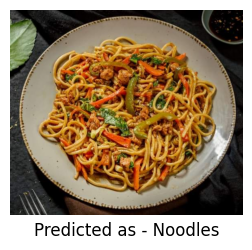

1/1 [==============================] - 0s 23ms/step


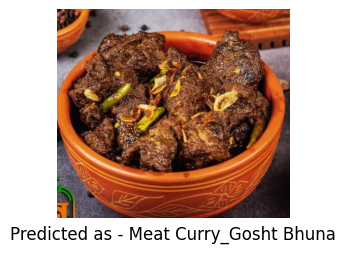

1/1 [==============================] - 0s 23ms/step


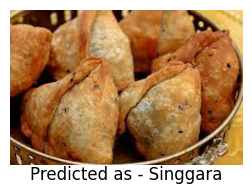

1/1 [==============================] - 0s 25ms/step


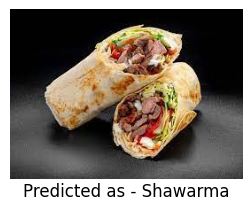

1/1 [==============================] - 0s 21ms/step


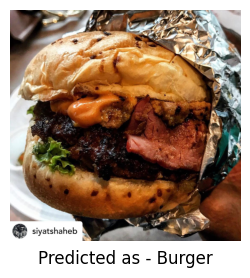

1/1 [==============================] - 0s 28ms/step


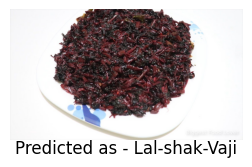

1/1 [==============================] - 0s 25ms/step


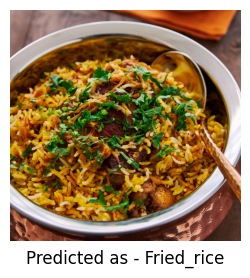

1/1 [==============================] - 0s 23ms/step


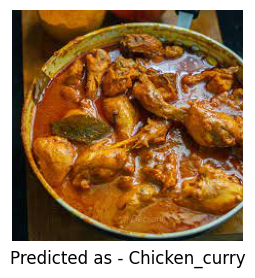

1/1 [==============================] - 0s 21ms/step


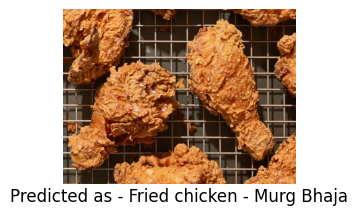

1/1 [==============================] - 0s 22ms/step


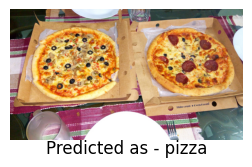

1/1 [==============================] - 0s 22ms/step


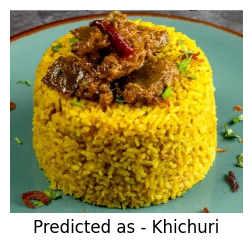

1/1 [==============================] - 0s 32ms/step


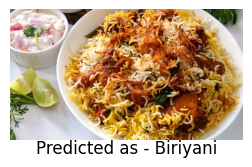

1/1 [==============================] - 0s 28ms/step


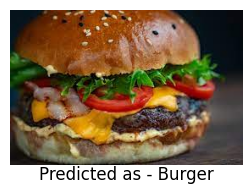

1/1 [==============================] - 0s 21ms/step


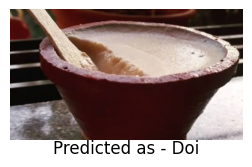

1/1 [==============================] - 0s 32ms/step


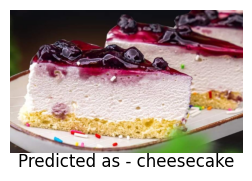

1/1 [==============================] - 0s 21ms/step


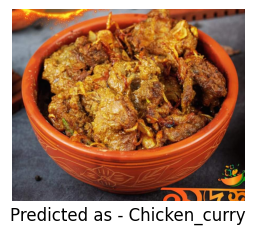

1/1 [==============================] - 0s 21ms/step


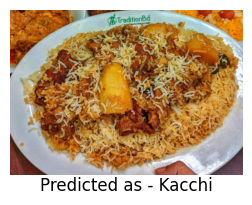

1/1 [==============================] - 0s 25ms/step


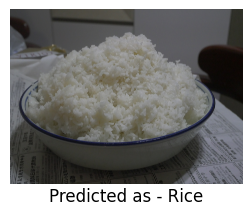

In [124]:
#Loop through directory and show images with prediction
source_directory = r'C:/Users/Rafin/OneDrive/Desktop/NSU/NSU 10th Semester/CSE299/PROJECT/CSE299.1_CalorieMate/MobileNet_Test_Images'
for subdirectory_name in os.listdir(source_directory):
     subdirectory_path = os.path.join(source_directory, subdirectory_name)
     image_path = subdirectory_path 
     
     img = output(subdirectory_path)
     
     label_text = ('Predicted as - %s'%(img))
     image = Image.open(image_path)
     fig, ax = plt.subplots(figsize=(3, 3))
     
     ax.imshow(image)
     ax.set_axis_off() 
     ax.text(0.5, -0.1, label_text, size=12, ha="center", transform=ax.transAxes)
     
     plt.show()